## EDA
---

In [241]:
import numpy as np
import pandas as pd

In [242]:
data = pd.read_csv(r"D:\Courses\DEPI R4 - Microsoft ML\Technical\Datasets\Data Analysis\stack-overflow-developer-survey-2020\survey_results_public.csv")

data.head()

,Respondent,MainBranch,Hobbyist,Age,Age1stCode,CompFreq,CompTotal,ConvertedComp,Country,CurrencyDesc,...,SurveyEase,SurveyLength,Trans,UndergradMajor,WebframeDesireNextYear,WebframeWorkedWith,WelcomeChange,WorkWeekHrs,YearsCode,YearsCodePro
0,1,I am a developer by profession,Yes,NaN,13,Monthly,NaN,NaN,Germany,European Euro,...,Neither easy nor difficult,Appropriate in length,No,"Computer science, computer engineering, or sof...",ASP.NET Core,ASP.NET;ASP.NET Core,Just as welcome now as I felt last year,50.0,36,27
1,2,I am a developer by profession,No,NaN,19,NaN,NaN,NaN,United Kingdom,Pound sterling,...,NaN,NaN,NaN,"Computer science, computer engineering, or sof...",NaN,NaN,Somewhat more welcome now than last year,NaN,7,4
2,3,I code primarily as a hobby,Yes,NaN,15,NaN,NaN,NaN,Russian Federation,NaN,...,Neither easy nor difficult,Appropriate in length,NaN,NaN,NaN,NaN,Somewhat more welcome now than last year,NaN,4,NaN
3,4,I am a developer by profession,Yes,25.0,18,NaN,NaN,NaN,Albania,Albanian lek,...,NaN,NaN,No,"Computer science, computer engineering, or sof...",NaN,NaN,Somewhat less welcome now than last year,40.0,7,4
4,5,"I used to be a developer by profession, but no...",Yes,31.0,16,NaN,NaN,NaN,United States,NaN,...,Easy,Too short,No,"Computer science, computer engineering, or sof...",Django;Ruby on Rails,Ruby on Rails,Just as welcome now as I felt last year,NaN,15,8


In [243]:
data.columns

Index(['Respondent', 'MainBranch', 'Hobbyist', 'Age', 'Age1stCode', 'CompFreq',
       'CompTotal', 'ConvertedComp', 'Country', 'CurrencyDesc',
       'CurrencySymbol', 'DatabaseDesireNextYear', 'DatabaseWorkedWith',
       'DevType', 'EdLevel', 'Employment', 'Ethnicity', 'Gender', 'JobFactors',
       'JobSat', 'JobSeek', 'LanguageDesireNextYear', 'LanguageWorkedWith',
       'MiscTechDesireNextYear', 'MiscTechWorkedWith',
       'NEWCollabToolsDesireNextYear', 'NEWCollabToolsWorkedWith', 'NEWDevOps',
       'NEWDevOpsImpt', 'NEWEdImpt', 'NEWJobHunt', 'NEWJobHuntResearch',
       'NEWLearn', 'NEWOffTopic', 'NEWOnboardGood', 'NEWOtherComms',
       'NEWOvertime', 'NEWPurchaseResearch', 'NEWPurpleLink', 'NEWSOSites',
       'NEWStuck', 'OpSys', 'OrgSize', 'PlatformDesireNextYear',
       'PlatformWorkedWith', 'PurchaseWhat', 'Sexuality', 'SOAccount',
       'SOComm', 'SOPartFreq', 'SOVisitFreq', 'SurveyEase', 'SurveyLength',
       'Trans', 'UndergradMajor', 'WebframeDesireNextYear',
  

In [244]:
schema_questions = pd.read_csv(r"D:\Courses\DEPI R4 - Microsoft ML\Technical\Datasets\Data Analysis\stack-overflow-developer-survey-2020\survey_results_schema.csv", index_col="Column")

In [245]:
display(schema_questions)

,QuestionText
Column,
Respondent,Randomized respondent ID number (not in order ...
MainBranch,Which of the following options best describes ...
Hobbyist,Do you code as a hobby?
Age,What is your age (in years)? If you prefer not...
Age1stCode,At what age did you write your first line of c...
...,...
WebframeWorkedWith,Which web frameworks have you done extensive d...
WelcomeChange,"Compared to last year, how welcome do you feel..."
WorkWeekHrs,"On average, how many hours per week do you wor..."


In [246]:
schema_questions.QuestionText["YearsCodePro"]

'NOT including education, how many years have you coded professionally (as a part of your work)?'

In [247]:
# Data Preperation & Cleaning

# Data -> [Demographics, Programming Exp, Employment]

# 1 - Select subset of columns with the relevant data for our analysis.

selected_columns = [
    
    # Demographics
    "Country",
    "Age",
    "Gender",
    "EdLevel",
    "UndergradMajor",

    # Programming Exp
    "Hobbyist",
    "Age1stCode",
    "YearsCode",
    "YearsCodePro",
    "LanguageWorkedWith",
    "LanguageDesireNextYear",
    "NEWLearn",
    "NEWStuck",

    # Employment
    "Employment",
    "DevType",
    "WorkWeekHrs",
    "JobSat",
    "JobFactors",
    "NEWOvertime",
    "NEWEdImpt"
]

In [248]:
len(selected_columns)

20

In [249]:
survey = data[selected_columns].copy()

In [250]:
survey.shape

(64461, 20)

In [251]:
schema = schema_questions.QuestionText[selected_columns].copy()

In [252]:
schema.shape

(20,)

In [253]:
survey.info()

<class 'pandas.DataFrame'>
RangeIndex: 64461 entries, 0 to 64460
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 64072 non-null  str    
 1   Age                     45446 non-null  float64
 2   Gender                  50557 non-null  str    
 3   EdLevel                 57431 non-null  str    
 4   UndergradMajor          50995 non-null  str    
 5   Hobbyist                64416 non-null  str    
 6   Age1stCode              57900 non-null  str    
 7   YearsCode               57684 non-null  str    
 8   YearsCodePro            46349 non-null  str    
 9   LanguageWorkedWith      57378 non-null  str    
 10  LanguageDesireNextYear  54113 non-null  str    
 11  NEWLearn                56156 non-null  str    
 12  NEWStuck                54983 non-null  str    
 13  Employment              63854 non-null  str    
 14  DevType                 49370 non-null  str    
 

In [254]:
# At what age did you write your first line of code or program?

survey.Age1stCode.unique()

<StringArray>
[                  '13',                   '19',                   '15',
                   '18',                   '16',                   '14',
                   '12',                   '20',                   '42',
                    '8',                   '25',                   '22',
                   '30',                   '17',                   '21',
                   '10',                   '46',                    '9',
                    '7',                   '11',                    '6',
                    nan,                   '31',                   '29',
                    '5', 'Younger than 5 years',                   '28',
                   '38',                   '23',                   '27',
                   '41',                   '24',                   '53',
                   '26',                   '35',                   '32',
                   '40',                   '33',                   '36',
                   '54',             

In [255]:
# Deal with [Younger than 5 years, Older than 85]

# Replace text values with numeric approximations

survey["Age1stCode"] = survey["Age1stCode"].replace({
    "Younger than 5 years": 4,
    "Older than 85": 85
})

# OR Convert column to numeric
survey["Age1stCode"] = pd.to_numeric(survey["Age1stCode"], errors="coerce") # any non numeric value -> Nan
survey["YearsCode"] = pd.to_numeric(survey["YearsCode"], errors="coerce") # any non numeric value -> Nan
survey["YearsCodePro"] = pd.to_numeric(survey["YearsCodePro"], errors="coerce")

In [256]:
# After

survey.Age1stCode.unique()

array([13., 19., 15., 18., 16., 14., 12., 20., 42.,  8., 25., 22., 30.,
       17., 21., 10., 46.,  9.,  7., 11.,  6., nan, 31., 29.,  5.,  4.,
       28., 38., 23., 27., 41., 24., 53., 26., 35., 32., 40., 33., 36.,
       54., 48., 56., 45., 44., 34., 85., 39., 51., 68., 50., 37., 47.,
       43., 52., 64., 55., 58., 49., 76., 72., 73., 83., 63.])

In [257]:
survey.describe()

,Age,Age1stCode,YearsCode,YearsCodePro,WorkWeekHrs
count,45446.000000,57900.000000,56784.000000,44133.000000,41151.000000
mean,30.834111,15.410121,12.782051,8.869667,40.782174
std,9.585392,5.289951,9.490657,7.759961,17.816383
min,1.000000,4.000000,1.000000,1.000000,1.000000
25%,24.000000,12.000000,6.000000,3.000000,40.000000
50%,29.000000,15.000000,10.000000,6.000000,40.000000
75%,35.000000,18.000000,17.000000,12.000000,44.000000
max,279.000000,85.000000,50.000000,50.000000,475.000000


In [258]:
# Delete rows (10 < Age < 100)

survey.drop(survey[survey.Age < 10].index, inplace=True)

survey.drop(survey[survey.Age > 100].index, inplace=True)

In [259]:
survey["Age"].describe()

count    45436.000000
mean        30.834294
std          9.506982
min         10.000000
25%         24.000000
50%         29.000000
75%         35.000000
max         99.000000
Name: Age, dtype: float64

In [260]:
# (WorkWeekHrs = 20*7 = 140) then delete rows are greater than 140

survey.drop(survey[survey["WorkWeekHrs"] > 140].index, inplace=True)

In [261]:
survey["WorkWeekHrs"].describe()

count    41002.000000
mean        40.024395
std         10.630010
min          1.000000
25%         40.000000
50%         40.000000
75%         43.000000
max        140.000000
Name: WorkWeekHrs, dtype: float64

In [262]:
schema["Gender"]

'Which of the following describe you, if any? Please check all that apply. If you prefer not to answer, you may leave this question blank.'

In [263]:
survey["Gender"].value_counts()

Gender
Man                                                            45895
Woman                                                           3835
Non-binary, genderqueer, or gender non-conforming                385
Man;Non-binary, genderqueer, or gender non-conforming            121
Woman;Non-binary, genderqueer, or gender non-conforming           92
Woman;Man                                                         73
Woman;Man;Non-binary, genderqueer, or gender non-conforming       25
Name: count, dtype: int64

In [264]:
survey.where(~(survey["Gender"].str.contains(';', na=False)), np.nan, inplace=True) # ~ : Not - change True rows

,Country,Age,Gender,EdLevel,UndergradMajor,Hobbyist,Age1stCode,YearsCode,YearsCodePro,LanguageWorkedWith,LanguageDesireNextYear,NEWLearn,NEWStuck,Employment,DevType,WorkWeekHrs,JobSat,JobFactors,NEWOvertime,NEWEdImpt
0,Germany,NaN,Man,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",Yes,13.0,36.0,27.0,C#;HTML/CSS;JavaScript,C#;HTML/CSS;JavaScript,Once a year,Visit Stack Overflow;Go for a walk or other ph...,"Independent contractor, freelancer, or self-em...","Developer, desktop or enterprise applications;...",50.0,Slightly satisfied,"Languages, frameworks, and other technologies ...",Often: 1-2 days per week or more,Fairly important
1,United Kingdom,NaN,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Computer science, computer engineering, or sof...",No,19.0,7.0,4.0,JavaScript;Swift,Python;Swift,Once a year,Visit Stack Overflow;Go for a walk or other ph...,Employed full-time,"Developer, full-stack;Developer, mobile",NaN,Very dissatisfied,NaN,NaN,Fairly important
2,Russian Federation,NaN,NaN,NaN,NaN,Yes,15.0,4.0,NaN,Objective-C;Python;Swift,Objective-C;Python;Swift,Once a decade,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Albania,25.0,Man,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",Yes,18.0,7.0,4.0,NaN,NaN,Once a year,NaN,NaN,NaN,40.0,Slightly dissatisfied,Flex time or a flexible schedule;Office enviro...,Occasionally: 1-2 days per quarter but less th...,Not at all important/not necessary
4,United States,31.0,Man,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Computer science, computer engineering, or sof...",Yes,16.0,15.0,8.0,HTML/CSS;Ruby;SQL,Java;Ruby;Scala,Once a year,Call a coworker or friend;Visit Stack Overflow...,Employed full-time,NaN,NaN,NaN,NaN,NaN,Very important
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64456,United States,NaN,NaN,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",Yes,16.0,10.0,NaN,NaN,NaN,Once a decade,Call a coworker or friend,Employed full-time,Senior executive/VP,NaN,NaN,NaN,NaN,Very important
64457,Morocco,NaN,NaN,NaN,NaN,Yes,NaN,NaN,NaN,Assembly;Bash/Shell/PowerShell;C;C#;C++;Dart;G...,Assembly;Bash/Shell/PowerShell;C;C#;C++;Dart;G...,NaN,NaN,Employed full-time,NaN,NaN,NaN,NaN,NaN,NaN
64458,Viet Nam,NaN,NaN,Primary/elementary school,NaN,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64459,Poland,NaN,NaN,NaN,NaN,Yes,NaN,NaN,NaN,HTML/CSS,HTML/CSS;Java;JavaScript,Once a year,Call a coworker or friend;Visit Stack Overflow,Employed full-time,NaN,NaN,NaN,NaN,NaN,NaN


In [265]:
survey["Gender"].value_counts()

Gender
Man                                                  45895
Woman                                                 3835
Non-binary, genderqueer, or gender non-conforming      385
Name: count, dtype: int64

In [266]:
survey.sample(5)

,Country,Age,Gender,EdLevel,UndergradMajor,Hobbyist,Age1stCode,YearsCode,YearsCodePro,LanguageWorkedWith,LanguageDesireNextYear,NEWLearn,NEWStuck,Employment,DevType,WorkWeekHrs,JobSat,JobFactors,NEWOvertime,NEWEdImpt
3288,Spain,24.0,Man,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Computer science, computer engineering, or sof...",Yes,14.0,7.0,2.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...,C#;HTML/CSS;Python;TypeScript,Once a year,Call a coworker or friend;Visit Stack Overflow...,Employed full-time,"Designer;Developer, back-end;Developer, deskto...",38.0,Very satisfied,"Languages, frameworks, and other technologies ...",Rarely: 1-2 days per year or less,Very important
13278,The former Yugoslav Republic of Macedonia,22.0,Man,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","A humanities discipline (such as literature, h...",Yes,19.0,2.0,NaN,HTML/CSS;JavaScript;TypeScript,Go;Python,Every few months,Visit Stack Overflow;Go for a walk or other ph...,Employed full-time,"Developer, front-end",40.0,Very satisfied,NaN,Sometimes: 1-2 days per month but less than we...,Not at all important/not necessary
46320,Spain,33.0,Man,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Computer science, computer engineering, or sof...",Yes,17.0,16.0,10.0,Bash/Shell/PowerShell;C++;HTML/CSS;JavaScript;...,Bash/Shell/PowerShell;C++;HTML/CSS;JavaScript;...,Once a year,Meditate;Call a coworker or friend;Visit Stack...,Employed full-time,"Database administrator;Developer, back-end;Dev...",40.0,Slightly satisfied,"Flex time or a flexible schedule;Languages, fr...",Occasionally: 1-2 days per quarter but less th...,Very important
46019,Sweden,25.0,Man,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Information systems, information technology, o...",No,15.0,5.0,NaN,C#;C++;HTML/CSS;TypeScript,C#;HTML/CSS;TypeScript,Once every few years,Visit Stack Overflow;Go for a walk or other ph...,Employed full-time,"Developer, back-end;Developer, front-end",40.0,Very satisfied,Industry that I’d be working in;Flex time or a...,Sometimes: 1-2 days per month but less than we...,NaN
58887,Sweden,NaN,NaN,Some college/university study without earning ...,"Another engineering discipline (such as civil,...",Yes,10.0,24.0,6.0,Bash/Shell/PowerShell;C;JavaScript;Python,JavaScript;Python,Every few months,Meditate;Visit Stack Overflow;Go for a walk or...,Employed full-time,"Database administrator;Designer;Developer, bac...",35.0,Slightly satisfied,Flex time or a flexible schedule;Office enviro...,Sometimes: 1-2 days per month but less than we...,Somewhat important


## Visualization
---

In [267]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

sns.set_style("darkgrid")
matplotlib.rcParams["font.size"] = 14
matplotlib.rcParams["figure.figsize"] = (10, 5)
matplotlib.rcParams["figure.facecolor"] = "#FFFFFFFF"

In [268]:
# Country ??
schema.Country

'Where do you live?'

In [269]:
# Number of countries
survey.Country.nunique()

183

In [270]:
top_countries = survey.Country.value_counts().head(10)
top_countries

Country
United States     12371
India              8364
United Kingdom     3881
Germany            3864
Canada             2175
France             1884
Brazil             1804
Netherlands        1332
Poland             1259
Australia          1199
Name: count, dtype: int64

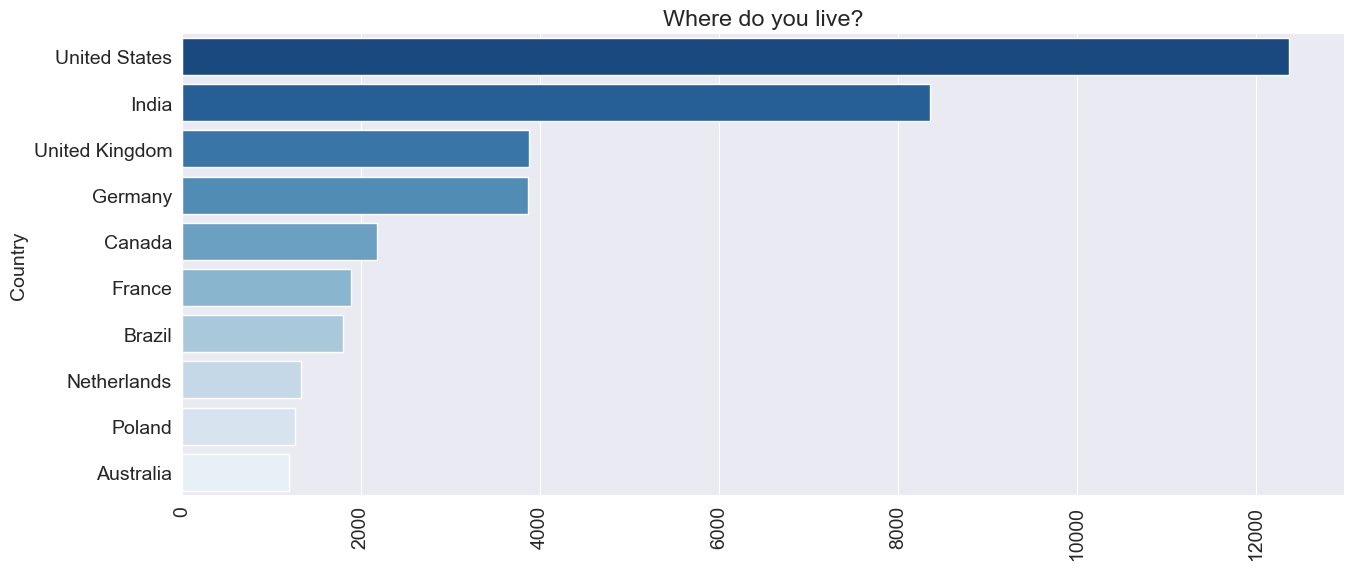

In [271]:
plt.figure(figsize=(15, 6))
plt.xticks(rotation=90) # pos of x labels
plt.title(schema.Country)
sns.barplot(x=top_countries.values, y=top_countries.index, palette="Blues_r", hue=top_countries.index)
plt.show()

In [272]:
# Age ??
schema.Age

'What is your age (in years)? If you prefer not to answer, you may leave this question blank.'

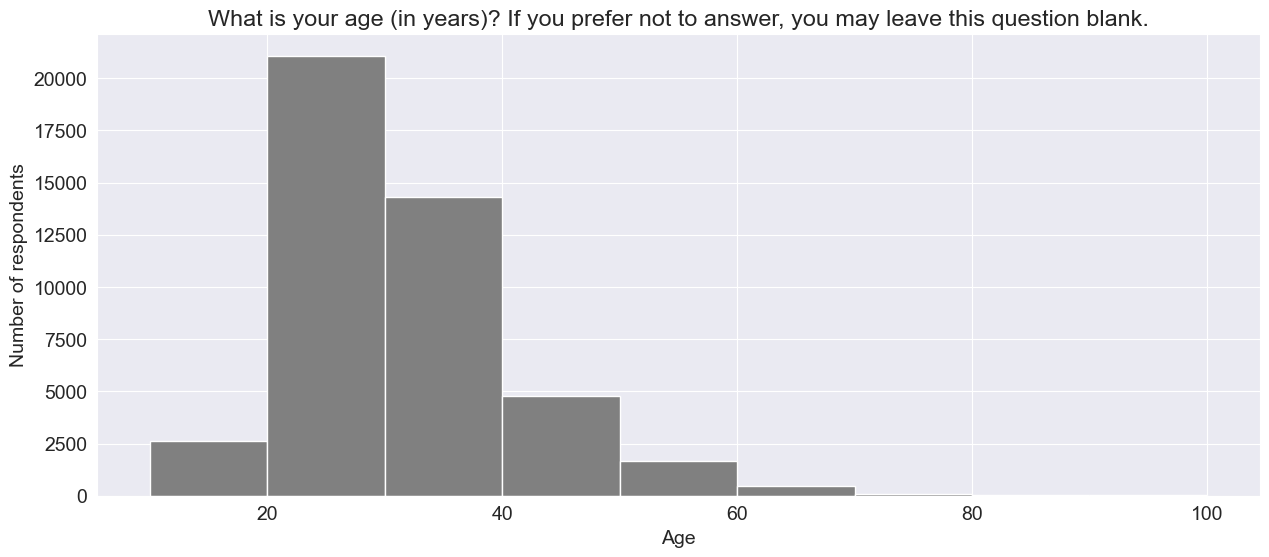

In [273]:
plt.figure(figsize=(15, 6))
plt.title(schema.Age)
plt.xlabel("Age")
plt.ylabel("Number of respondents")
plt.hist(x=survey.Age, bins=[10, 20, 30, 40, 50, 60, 70, 80, 90, 100], color="grey", edgecolor="white")
plt.show()

In [274]:
# Gender ??
schema.Gender

'Which of the following describe you, if any? Please check all that apply. If you prefer not to answer, you may leave this question blank.'

In [275]:
gender_counts = survey.Gender.value_counts()
gender_counts

Gender
Man                                                  45895
Woman                                                 3835
Non-binary, genderqueer, or gender non-conforming      385
Name: count, dtype: int64

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


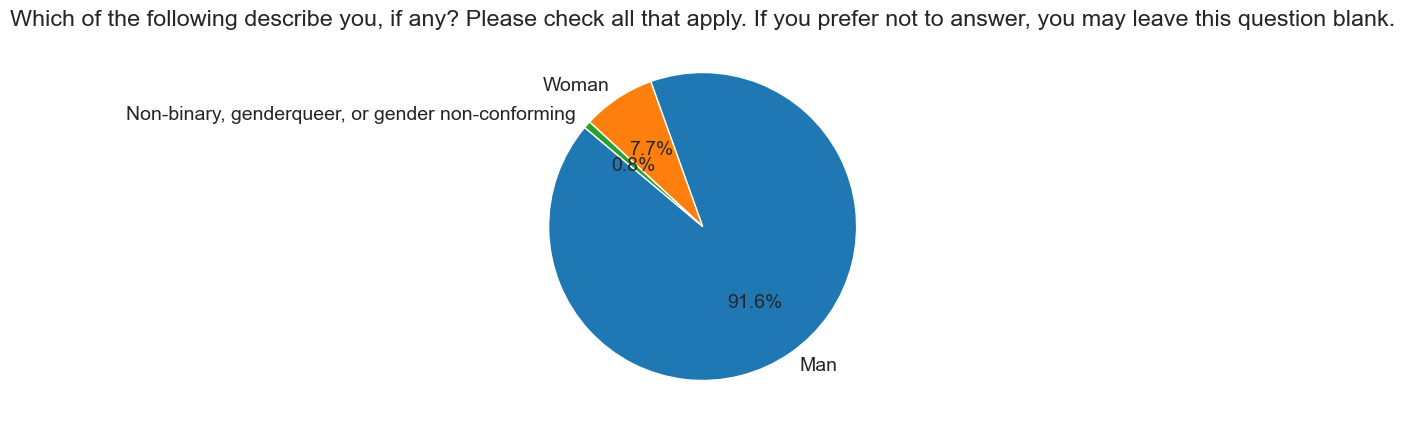

In [276]:
plt.figure(figsize=(16, 5))
plt.axis('equal')
plt.title(schema.Gender)
plt.pie(x=gender_counts.values, labels=gender_counts.index, autopct="%1.1f%%", startangle=140) # type: ignore
plt.show()

In [277]:
# EdLevel ??
schema.EdLevel

'Which of the following best describes the highest level of formal education that you’ve completed?'

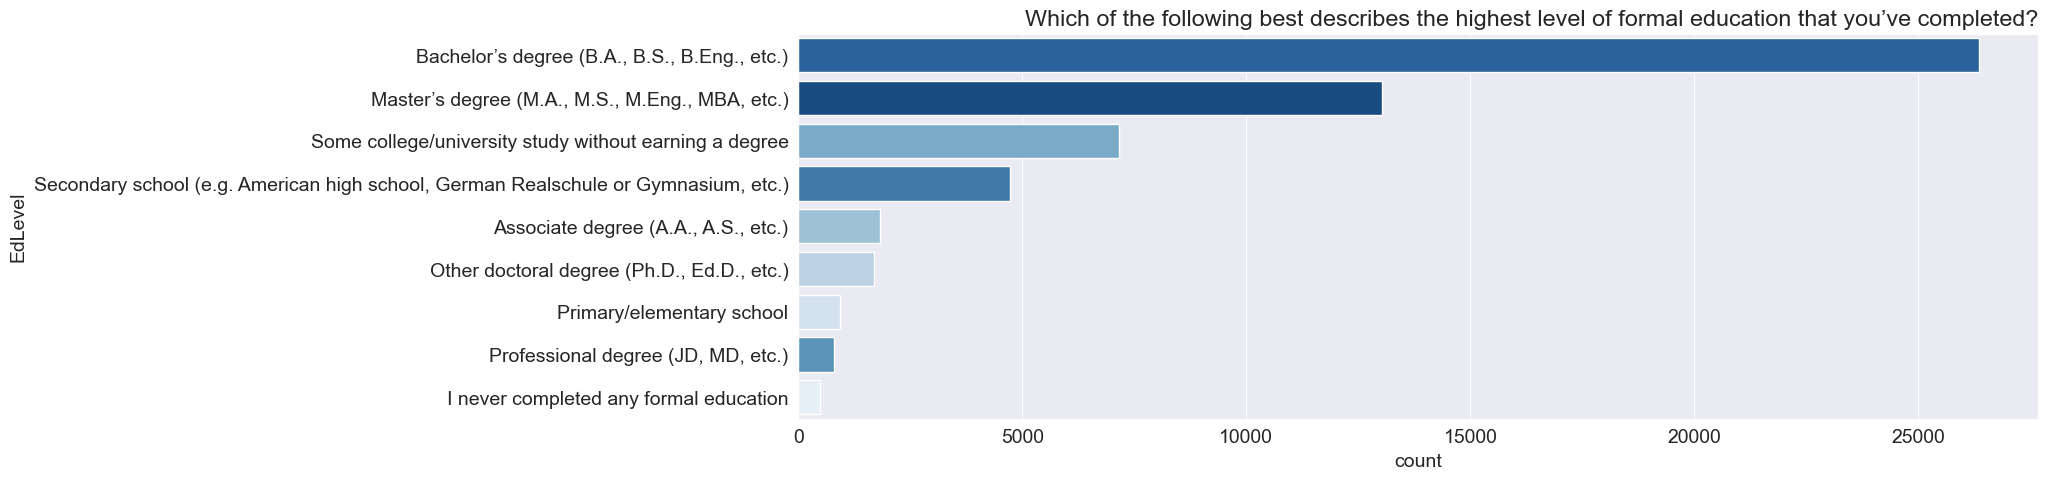

In [278]:
plt.figure(figsize=(16, 5))
sns.countplot(y=survey.EdLevel, order=survey.EdLevel.value_counts().index, palette="Blues_r", hue=survey.EdLevel, legend=False)
plt.xticks()
plt.title(schema.EdLevel, loc="right")
plt.show()

In [279]:
# Under grade major ??
schema.UndergradMajor

'What was your primary field of study?'

In [280]:
undergrade_percentage = survey.UndergradMajor.value_counts() * 100 / survey.UndergradMajor.count()
undergrade_percentage

UndergradMajor
Computer science, computer engineering, or software engineering                   61.939193
Another engineering discipline (such as civil, electrical, mechanical, etc.)       9.354195
Information systems, information technology, or system administration              7.983168
A natural science (such as biology, chemistry, physics, etc.)                      4.316561
Mathematics or statistics                                                          3.627097
Web development or web design                                                      3.502637
A business discipline (such as accounting, finance, marketing, etc.)               2.700567
A humanities discipline (such as literature, history, philosophy, etc.)            1.969616
A social science (such as anthropology, psychology, political science, etc.)       1.821450
Fine arts or performing arts (such as graphic design, music, studio art, etc.)     1.412513
I never declared a major                                         

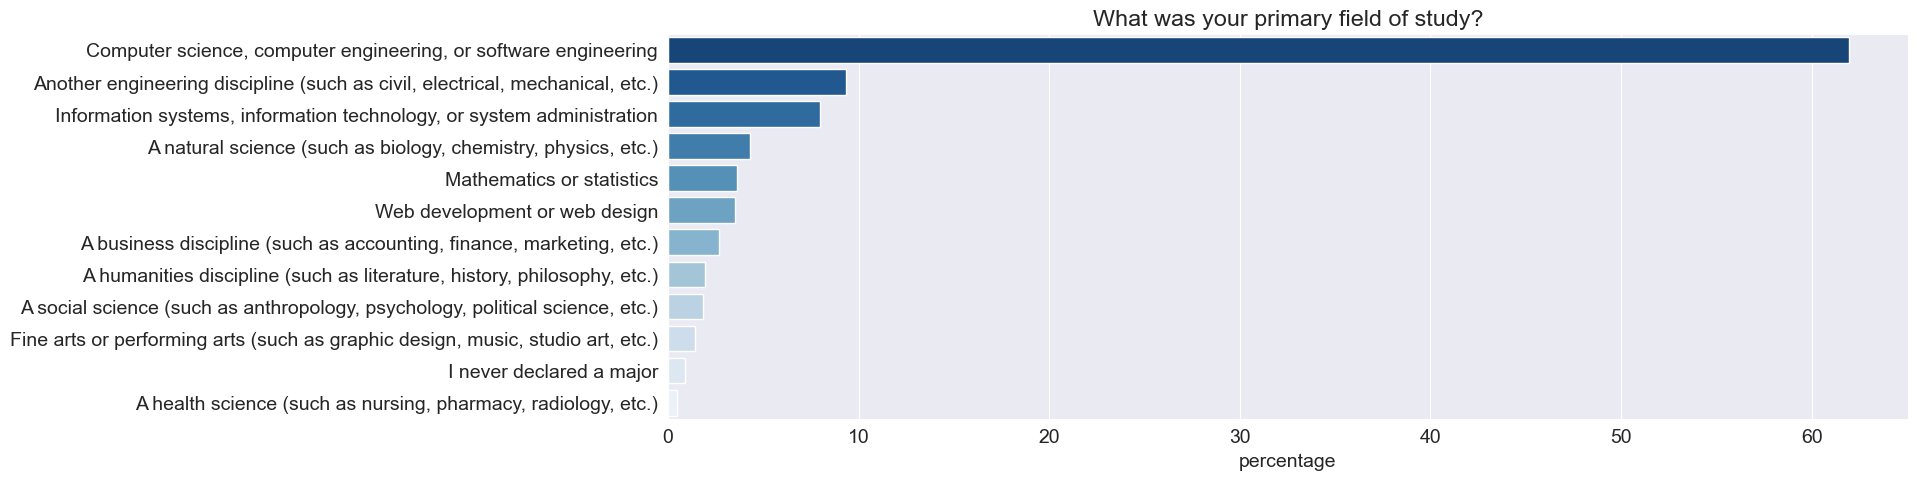

In [281]:
plt.figure(figsize=(16, 5))
sns.barplot(x=undergrade_percentage.values, y=undergrade_percentage.index, palette="Blues_r", hue=undergrade_percentage.index)
plt.title(schema.UndergradMajor)
plt.ylabel(None)
plt.xlabel("percentage")
plt.show()

In [282]:
# Employment ??
schema.Employment

'Which of the following best describes your current employment status?'

In [283]:
schema.Employment

'Which of the following best describes your current employment status?'

In [284]:
emp_counts = survey.Employment.value_counts()
emp_counts

Employment
Employed full-time                                      44958
Student                                                  7734
Independent contractor, freelancer, or self-employed     5619
Not employed, but looking for work                       2324
Employed part-time                                       2200
Not employed, and not looking for work                    318
Retired                                                   241
Name: count, dtype: int64

In [285]:
employmnet_percentage = survey.Employment.value_counts() * 100 / survey.Employment.count()
employmnet_percentage

Employment
Employed full-time                                      70.918383
Student                                                 12.199893
Independent contractor, freelancer, or self-employed     8.863615
Not employed, but looking for work                       3.665962
Employed part-time                                       3.470360
Not employed, and not looking for work                   0.501625
Retired                                                  0.380162
Name: count, dtype: float64

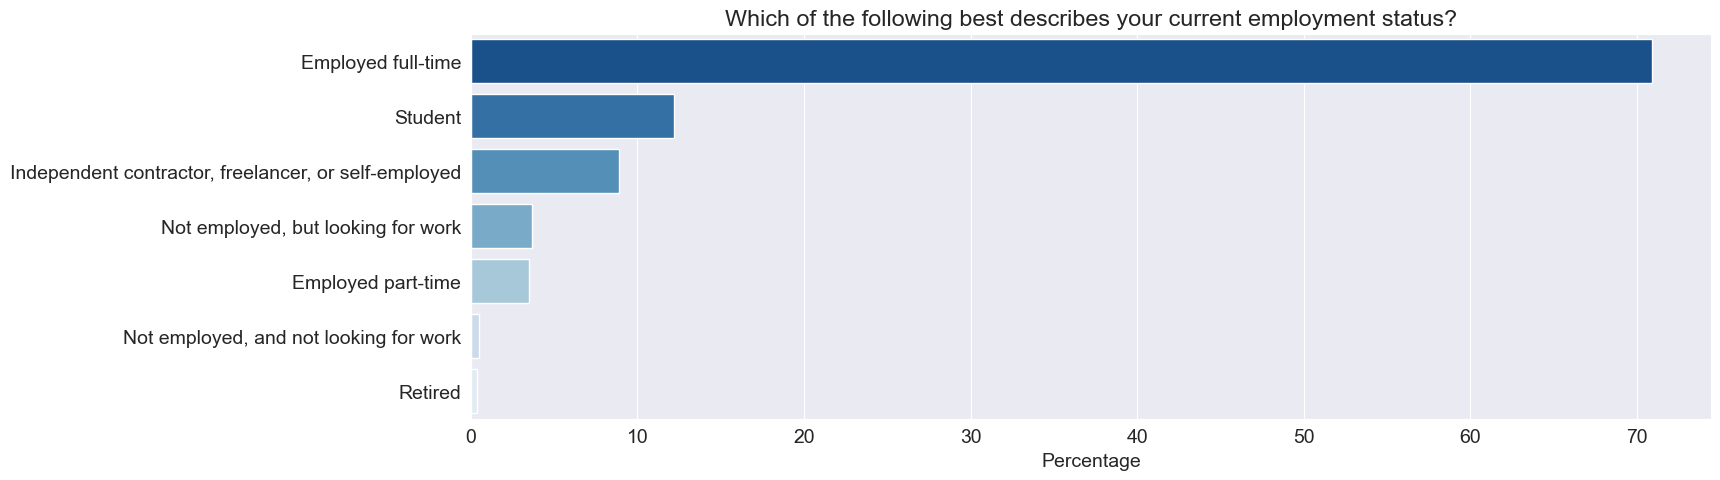

In [286]:
plt.figure(figsize=(16, 5))
sns.barplot(x=employmnet_percentage, y=employmnet_percentage.index, palette="Blues_r", hue=employmnet_percentage.index)
plt.title(schema.Employment)
plt.ylabel(None)
plt.xlabel("Percentage")
plt.show()

In [287]:
# DevType ??
schema.DevType

'Which of the following describe you? Please select all that apply.'

In [288]:
survey.DevType.value_counts()

DevType
Developer, full-stack                                                                                                                                                                                                                                                                                                                                                                                                 4396
Developer, back-end                                                                                                                                                                                                                                                                                                                                                                                                   3056
Developer, back-end;Developer, front-end;Developer, full-stack                                                                                                            

In [291]:
def split_mulcolumns(col_series):
    result = col_series.to_frame()
    options = []

    for idx, value in col_series[col_series.notnull()].items():
        for option in value.split(';'):
            if not option in result.columns:
                options.append(option)
                result[option] = False

            result.at[idx, option] = True
    return result[options]

In [294]:
dev_type = split_mulcolumns(survey.DevType)
display(dev_type.head())

,"Developer, desktop or enterprise applications","Developer, full-stack","Developer, mobile",Designer,"Developer, front-end","Developer, back-end","Developer, QA or test",DevOps specialist,"Developer, game or graphics",Database administrator,...,System administrator,Engineering manager,Product manager,Data or business analyst,Academic researcher,Data scientist or machine learning specialist,Scientist,Senior executive/VP,"Engineer, site reliability",Marketing or sales professional
0,True,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [297]:
dev_type_counts = dev_type.sum().sort_values(ascending=False)
dev_type_counts

Developer, back-end                              26996
Developer, full-stack                            26915
Developer, front-end                             18128
Developer, desktop or enterprise applications    11687
Developer, mobile                                 9406
DevOps specialist                                 5915
Database administrator                            5658
Designer                                          5262
System administrator                              5185
Developer, embedded applications or devices       4701
Data or business analyst                          3970
Data scientist or machine learning specialist     3939
Developer, QA or test                             3893
Engineer, data                                    3700
Academic researcher                               3502
Educator                                          2895
Developer, game or graphics                       2751
Engineering manager                               2699
Product ma